In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import matplotlib.pyplot as plt
from ensemble_rbm import load_ensemble_results
from jax import jit

In [2]:
directory = '/home/shailesh/Projects/Local/BoltzmannMachine/Claude/ising_576_statistics/'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

hamiltonian_data = {}
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    for instance in ens:
        hamiltonian_data[sector].append((instance['W'],instance['bv'],instance['bh']))

In [3]:
def visualize_torus_modes(U_K, sector_name, L=24):
    """
    Plots the top 2 principal components as 2D spatial maps on the torus.
    U_K shape: (V, K) where V = L*L
    """
    # Extract the first two principal components
    mode_1 = U_K[:, 0].reshape(L, L)
    mode_2 = U_K[:, 1].reshape(L, L)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mode 1
    im1 = axes[0].imshow(mode_1, cmap='RdBu', origin='lower')
    axes[0].set_title(f"{sector_name} - Dominant Mode 1")
    fig.colorbar(im1, ax=axes[0])
    
    # Mode 2
    im2 = axes[1].imshow(mode_2, cmap='RdBu', origin='lower')
    axes[1].set_title(f"{sector_name} - Dominant Mode 2")
    fig.colorbar(im2, ax=axes[1])
    
    plt.suptitle(f"Spatial Visualization of Normal Modes on the Torus")
    plt.tight_layout()
    plt.show()

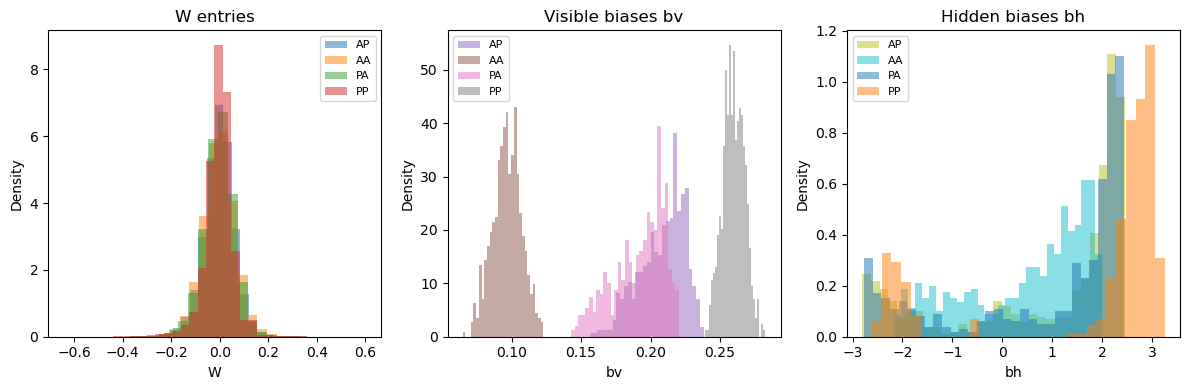

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define colors for sectors
import itertools
colors = itertools.cycle(plt.cm.tab10.colors)

# Parameters to plot
keys = ["W", "bv", "bh"]#, "W_fro", "W_svd", "bias_asym"]
titles = {
    "W": "W entries",
    "bv": "Visible biases bv",
    "bh": "Hidden biases bh",
    "W_fro": "Frobenius norm(W)",
    "W_svd": "Spectral norm(W)",
    "bias_asym": "Mean(bv) - Mean(bh)"
}

fig, axes = plt.subplots(1, len(keys), figsize=(4*len(keys), 4), sharex=False)

if len(keys) == 1:
    axes = [axes]

for j, k in enumerate(keys):
    ax = axes[j]
    for sector, data in sector_data.items():
        ax.hist(data[k], bins=30, alpha=0.5, density=True, 
                color=next(colors), label=str(sector))
    ax.set_title(titles[k])
    ax.set_xlabel(k)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rbm_parameter_spread.pdf')
plt.show()

In [10]:
@jit
def compute_weak_coupling_J(W, bh):
    """
    Computes the effective pairwise J matrix in the small-weight limit
    when W is shaped as (H, V).
    """
    # W shape: (H, V) where H is hidden, V is visible
    H, V = W.shape
    
    # Compute the variance of the hidden units: shape (H,)
    sigma = jax.nn.sigmoid(bh)
    variance = sigma * (1.0 - sigma) 
    
    # Scale the weights across the hidden dimension.
    # Since W is (H, V) and variance is (H,), we broadcast along the first axis.
    # variance[:, None] gives shape (H, 1), which broadcasts perfectly over (H, V)
    W_scaled = W * jnp.sqrt(variance)[:, None]
    
    # Since W_scaled is (H, V), to get a (V, V) interaction matrix,
    # we take the dot product of its transpose with itself: (V, H) @ (H, V)
    J = (1.0 / 8.0) * jnp.dot(W_scaled.T, W_scaled)
    
    # Zero out diagonal to avoid self-interaction loops
    J = J * (1.0 - jnp.eye(V))
    return J

(576, 20)


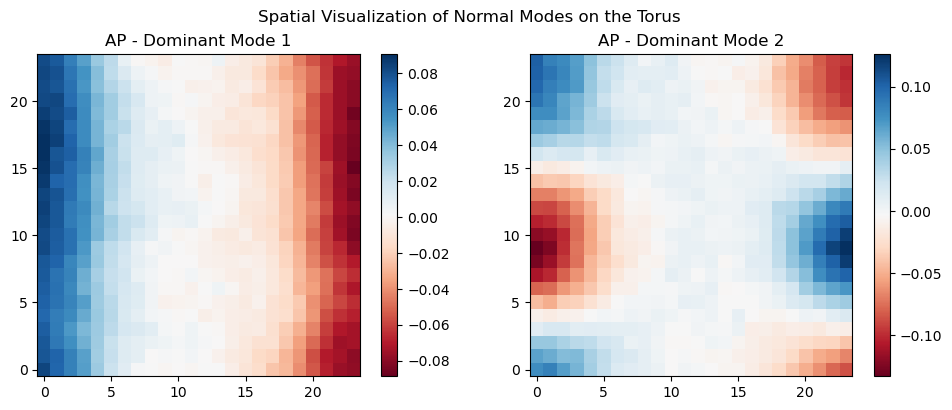


Sector: AP
-> Top 3 Eigenvalues: [1.477417   1.0929053  1.0430611  0.83011717 0.79727745 0.76527697
 0.7159624  0.6686046  0.6489698  0.602531   0.5986149  0.57426494
 0.5698528  0.51129955 0.50469816 0.46005416 0.45185015 0.44403934
 0.4353097  0.42045683]
-> Generated configurations matrix shape: (5, 576)
(576, 20)


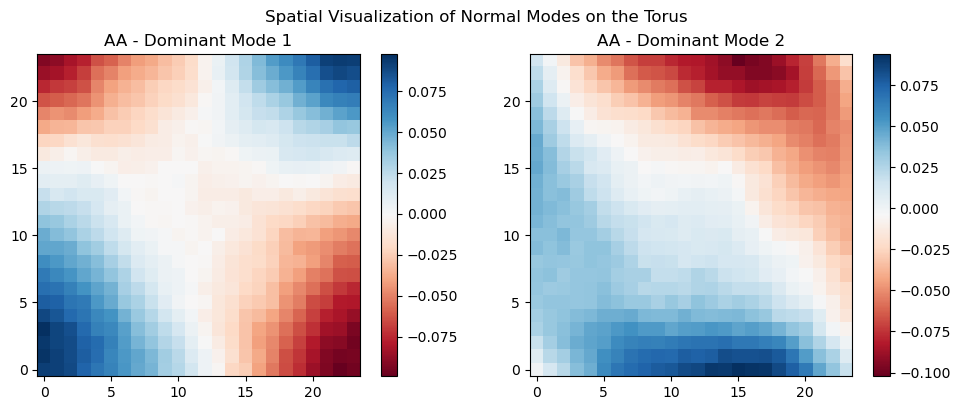


Sector: AA
-> Top 3 Eigenvalues: [1.6603401  1.5570903  1.5216781  1.0756476  1.0628432  1.0546743
 1.0231035  0.98486865 0.9565878  0.9231705  0.90003204 0.8413919
 0.81676954 0.7899725  0.77435744 0.73852366 0.723762   0.71385765
 0.70047456 0.6957201 ]
-> Generated configurations matrix shape: (5, 576)
(576, 20)


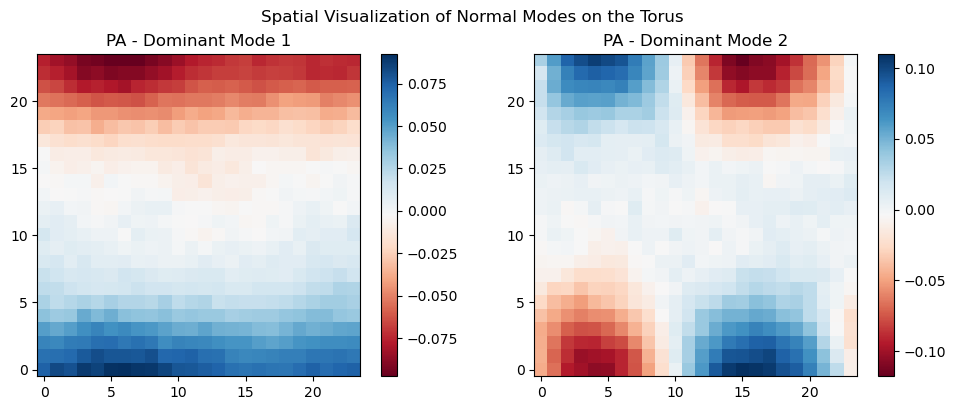


Sector: PA
-> Top 3 Eigenvalues: [1.4929504  1.1504974  1.0544964  0.8096701  0.78062046 0.76271355
 0.7208698  0.67571473 0.65673256 0.6268909  0.6198463  0.6046928
 0.5737572  0.51448643 0.5051589  0.4858785  0.4609679  0.45583746
 0.45134532 0.43602937]
-> Generated configurations matrix shape: (5, 576)
(576, 20)


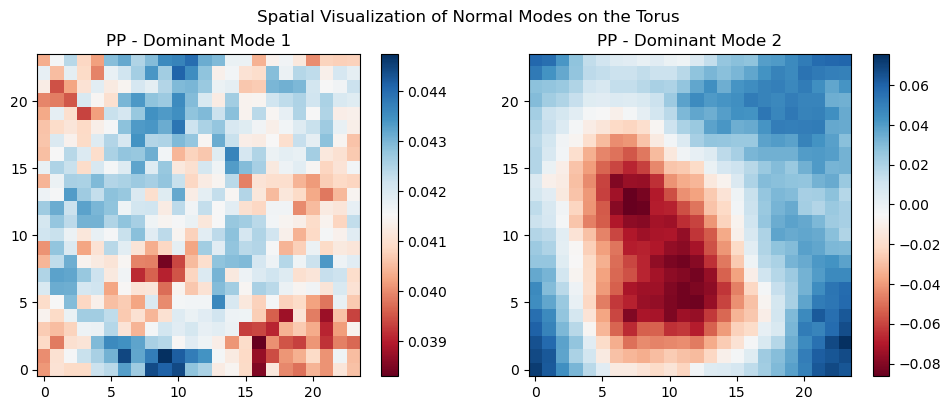


Sector: PP
-> Top 3 Eigenvalues: [2.5550125  0.4754555  0.4563254  0.43850648 0.42357966 0.417706
 0.4098777  0.40589556 0.39174247 0.36380962 0.35148203 0.33598658
 0.33281723 0.32423386 0.31686327 0.3015178  0.29867142 0.29583892
 0.2880138  0.28206956]
-> Generated configurations matrix shape: (5, 576)


In [12]:
def visualize_torus_modes(U_K, sector_name, L=24):
    """
    Plots the top 2 principal components as 2D spatial maps on the torus.
    U_K shape: (V, K) where V = L*L
    """
    # Extract the first two principal components
    mode_1 = U_K[:, 0].reshape(L, L)
    mode_2 = U_K[:, 1].reshape(L, L)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mode 1
    im1 = axes[0].imshow(mode_1, cmap='RdBu', origin='lower')
    axes[0].set_title(f"{sector_name} - Dominant Mode 1")
    fig.colorbar(im1, ax=axes[0])
    
    # Mode 2
    im2 = axes[1].imshow(mode_2, cmap='RdBu', origin='lower')
    axes[1].set_title(f"{sector_name} - Dominant Mode 2")
    fig.colorbar(im2, ax=axes[1])
    
    plt.suptitle(f"Spatial Visualization of Normal Modes on the Torus")
    plt.tight_layout()
    plt.show()

def sample_from_sector_pca(key, sector_instances, K, num_samples=1000):
    """
    Computes a collective PCA basis for a given sector by averaging its 
    analytic J matrices, then samples configurations along those top K modes.
    """
    # Grab dimensions from the first instance
    sample_W, sample_bv, sample_bh = sector_instances[0]
    H, V = sample_W.shape
    
    # 1. Accumulate and average the analytic J matrices across all instances in this sector
    J_total = jnp.zeros((V, V))
    for W, bv, bh in sector_instances:
        # Ensure data is converted to device arrays
        W_arr = jnp.array(W, dtype=jnp.float32)
        bh_arr = jnp.array(bh, dtype=jnp.float32)
        J_total += compute_weak_coupling_J(W_arr, bh_arr)
        
    J_avg = J_total / len(sector_instances)
    
    # 2. Extract principal components via EIGH
    eigenvalues, eigenvectors = jnp.linalg.eigh(J_avg)
    
    # Sort from largest to smallest eigenvalue
    eigenvalues = jnp.flip(eigenvalues)
    U = jnp.flip(eigenvectors, axis=1)
    
    # Truncate to top K principal directions
    U_K = U[:, :K]
    sigma_K = jnp.sqrt(jnp.abs(eigenvalues[:K])) # Standard deviation of the modes
    
    # 3. Sample continuous fluctuations in the latent subspace
    k1, k2 = jax.random.split(key)
    latent_samples = jax.random.normal(k1, (num_samples, K)) * sigma_K[None, :]
    
    # 4. Project back to physical real-space and squash to binary boundaries [0, 1]
    # We use a neutral 0.5 background mean for the spins
    v_mean = 0.5 * jnp.ones((V,))
    v_continuous = v_mean[None, :] + jnp.dot(latent_samples, U_K.T)
    v_sampled_configs = jax.nn.sigmoid(v_continuous)
    
    return v_sampled_configs, U_K, eigenvalues

# --- Execution Over All Sectors ---
if __name__ == "__main__":
    import numpy as np
            
    # Process and sample
    rng_key = jax.random.PRNGKey(1234)
    K_modes = 20  # Keep the top 4 dominant modes
    
    sampled_results = {}
    for sector, instances in hamiltonian_data.items():
        rng_key, subkey = jax.random.split(rng_key)
        
        v_samples, U_K, spectrum = sample_from_sector_pca(subkey, instances, K=K_modes, num_samples=5)
        print(U_K.shape)
        sampled_results[sector] = v_samples
        visualize_torus_modes(U_K, sector)
        
        print(f"\nSector: {sector}")
        print(f"-> Top 3 Eigenvalues: {spectrum[:K_modes]}")
        print(f"-> Generated configurations matrix shape: {v_samples.shape}")

In [ ]:
directory = '/home/shailesh/Projects/Local/BoltzmannMachine/Claude/ising_576_statistics/'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

hamiltonian_data = {}
hamiltonians = []
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    for instance in ens:
        W, bv, bh = (instance['W'],instance['bv'],instance['bh'])
        hamiltonian_data[sector].append((W,bv,bh))
        

In [75]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

def plot_leading_modes_across_sectors(sector_eigenvectors, L=24):
    """
    Plots the leading eigenmode (first principal component) of each sector in a 1xN grid.
    
    sector_eigenvectors: dict of {sector_name: U_K array of shape (V, K)}
    """
    n_sectors = len(sector_eigenvectors)
    fig, axes = plt.subplots(1, n_sectors, figsize=(4*n_sectors, 4))
    
    if n_sectors == 1:
        axes = [axes]
    
    for i, (sector, U_K) in enumerate(sector_eigenvectors.items()):
        mode_1 = U_K[:, 0].reshape(L, L)
        im = axes[i].imshow(mode_1, cmap='RdBu', origin='lower')
        axes[i].set_title(f"{sector} - Mode 1")
        axes[i].axis('off')
        fig.colorbar(im, ax=axes[i])
    
    #plt.suptitle("Leading Eigenmode Across Sectors", fontsize=16)
    plt.tight_layout()
    plt.savefig('eigenmode.pdf')
    plt.show()


def plot_eigenvalue_spectra(sector_eigenvalues, top_n=10):
    """
    Plots the top_n eigenvalues of each sector overlaid on a log scale.
    
    sector_eigenvalues: dict of {sector_name: eigenvalues array sorted descending}
    """
    plt.figure(figsize=(6, 4))
    
    for sector, eigvals in sector_eigenvalues.items():
        plt.plot(
            np.arange(1, top_n+1),
            np.array(np.abs(eigvals[:top_n])),
            marker='o',
            label=str(sector),alpha = 0.2
        )
    
    plt.yscale('log')
    plt.xlabel("Mode index")
    plt.ylabel("Eigenvalue (log scale)")
    #plt.title(f"Top {top_n} Eigenvalues Across Sectors")
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.2)
    plt.savefig('leading_eigenval.pdf')
    plt.tight_layout()
    plt.show()


# --- Execution Over All Sectors ---
if __name__ == "__main__":
    rng_key = jax.random.PRNGKey(1234)
    K_modes = 20 #20  # Keep the top 20 dominant modes
    
    sector_UK = {}
    sector_spectra = {}
    
    for sector, instances in hamiltonian_data.items():
        rng_key, subkey = jax.random.split(rng_key)
        
        _, U_K, eigenvalues = sample_from_sector_pca(subkey, instances, K=K_modes, num_samples=5)
        sector_UK[sector] = np.array(U_K)  # convert to NumPy for plotting
        sector_spectra[sector] = np.array(np.flip(eigenvalues))  # descending
        
    # 1. Leading eigenmode plot (1 row, N sectors)
    #plot_leading_modes_across_sectors(sector_UK, L=24)
    
    # 2. Top 10 eigenvalues overlaid
    #plot_eigenvalue_spectra(sector_spectra, top_n=500)

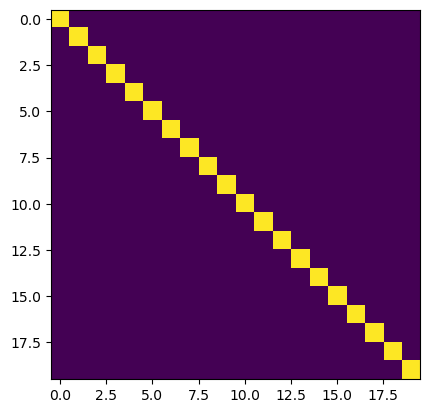

In [76]:
plt.imshow(sector_UK['AP'].T@sector_UK['AP'])

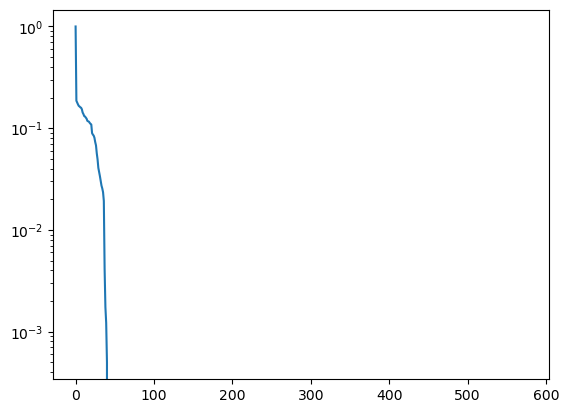

In [81]:
plt.semilogy(np.flip(sector_spectra['PP']/np.max(sector_spectra['PP'])))


In [28]:
def plot_leading_modes_across_sectors_trimmed(sector_eigenvectors, L=24, trim_percentile=99):
    """
    Plots the leading eigenmode (first principal component) of each sector in a 1xN grid.
    Colorbar is trimmed to remove extreme outliers.
    
    sector_eigenvectors: dict of {sector_name: U_K array of shape (V, K)}
    trim_percentile: percentile for symmetric clipping, e.g., 99 -> clip to [-p,p]
    """
    n_sectors = len(sector_eigenvectors)
    
    # Determine global symmetric color limits
    all_modes = np.concatenate([U_K[:, 0] for U_K in sector_eigenvectors.values()])
    vmax = np.percentile(np.abs(all_modes), trim_percentile)
    vmin = -vmax
    
    fig, axes = plt.subplots(1, n_sectors, figsize=(4*n_sectors, 4))
    
    if n_sectors == 1:
        axes = [axes]
    
    for i, (sector, U_K) in enumerate(sector_eigenvectors.items()):
        mode_1 = U_K[:, 0].reshape(L, L)
        im = axes[i].imshow(mode_1, cmap='RdBu', origin='lower', vmin=vmin, vmax=vmax)
        #axes[i].set_title(f"{sector} - Mode 1")
        axes[i].axis('off')
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)  # smaller colorbar
    
    #plt.suptitle("Leading Eigenmode Across Sectors (Trimmed Color Scale)", fontsize=16)
    plt.tight_layout()
    plt.savefig('leading_eigenmodes.pdf')
    plt.show()

In [68]:
sector_UK['PP'].shape

(576, 20)

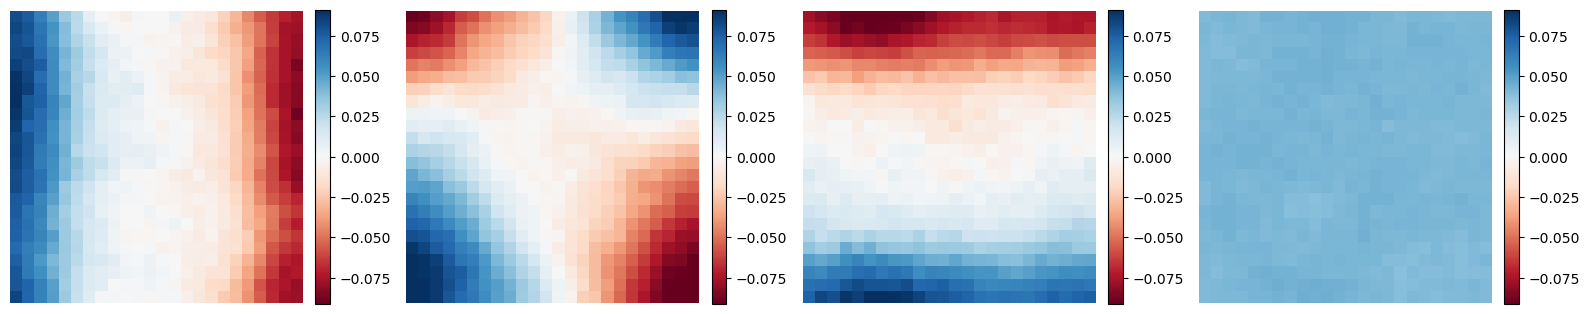

In [29]:
# --- Execution Over All Sectors ---
if __name__ == "__main__":
    rng_key = jax.random.PRNGKey(1234)
    K_modes = 20  # Keep the top 20 dominant modes
    
    sector_UK = {}
    sector_spectra = {}
    
    for sector, instances in hamiltonian_data.items():
        rng_key, subkey = jax.random.split(rng_key)
        
        _, U_K, eigenvalues = sample_from_sector_pca(subkey, instances, K=K_modes, num_samples=5)
        sector_UK[sector] = np.array(U_K)  # convert to NumPy for plotting
        sector_spectra[sector] = np.array(np.flip(eigenvalues))  # descending
        
    # 1. Leading eigenmode plot (1 row, N sectors)
    plot_leading_modes_across_sectors_trimmed(sector_UK, L=24)

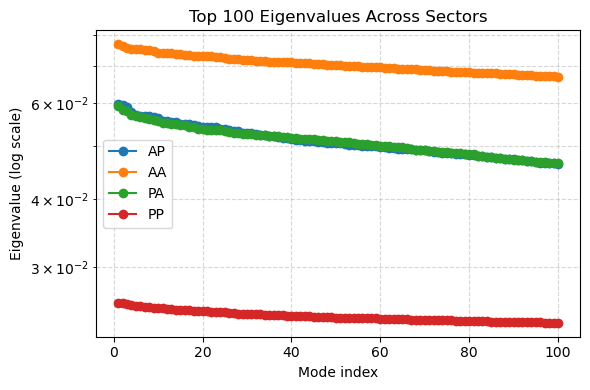

In [24]:
# 2. Top 10 eigenvalues overlaid
plot_eigenvalue_spectra(sector_spectra, top_n=100)

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_eigenvalue_decay(sector_spectra, n_modes=None):
    """
    Compare eigenvalue decay across sectors.

    sector_spectra:
        dict
            sector -> eigenvalues (already sorted largest -> smallest)

    n_modes:
        Number of leading modes to display.
        None = show entire spectrum.
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax1, ax2 = axes

    for sector, eigs in sector_spectra.items():

        eigs = np.asarray(eigs)

        # Remove tiny negative numerical errors
        eigs = np.abs(eigs)

        if n_modes is not None:
            eigs = eigs[:n_modes]

        k = np.arange(1, len(eigs) + 1)

        # semi-log
        ax1.semilogy(
            k,
            eigs,
            marker='o',
            markersize=3,
            linewidth=1.5,
            label=str(sector)
        )

        # log-log
        ax2.loglog(
            k,
            eigs,
            marker='o',
            markersize=3,
            linewidth=1.5,
            label=str(sector)
        )

    ax1.set_xlabel("Mode index")
    ax1.set_ylabel("Eigenvalue")
    ax1.set_title("Semi-log spectrum")
    ax1.grid(True, which="both", alpha=0.3)

    ax2.set_xlabel("Mode index")
    ax2.set_ylabel("Eigenvalue")
    ax2.set_title("Log-log spectrum")
    ax2.grid(True, which="both", alpha=0.3)

    ax2.legend()

    plt.tight_layout()
    plt.show()

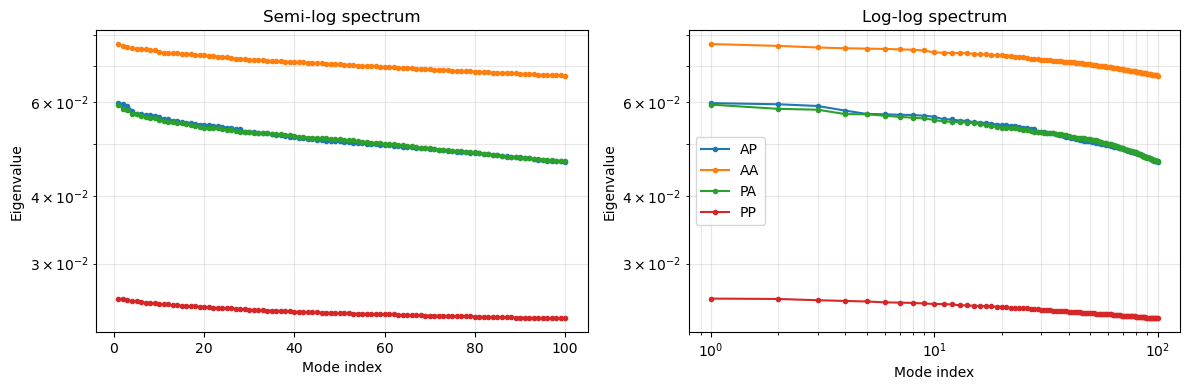

In [32]:
plot_eigenvalue_decay(sector_spectra, n_modes=100)

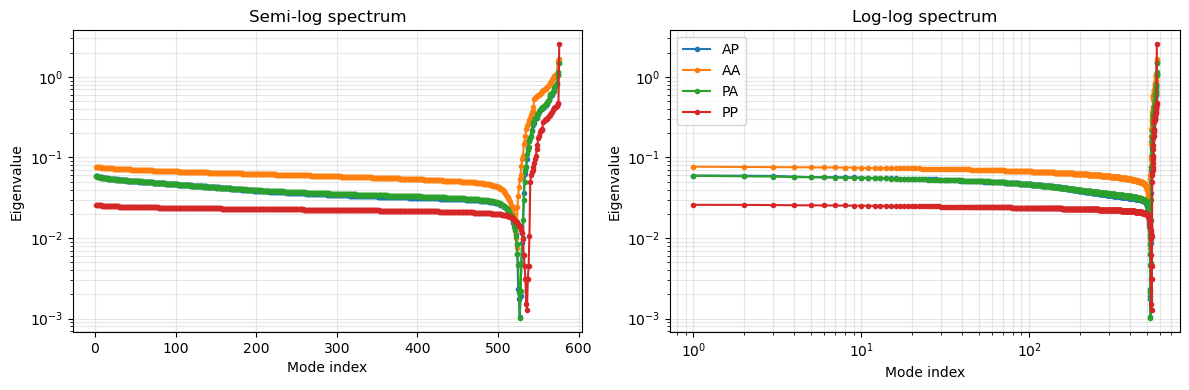

In [33]:
plot_eigenvalue_decay(sector_spectra)

In [34]:
def fit_power_law(eigs, kmin=10, kmax=100):
    eigs = np.abs(np.asarray(eigs))
    k = np.arange(1, len(eigs)+1)

    x = np.log(k[kmin:kmax])
    y = np.log(eigs[kmin:kmax])

    alpha, intercept = np.polyfit(x, y, 1)

    print(f"lambda_k ~ k^({alpha:.3f})")

    return alpha

In [36]:
fit_power_law(sector_spectra['PP'])

lambda_k ~ k^(-0.029)


np.float64(-0.028982525368302207)

In [37]:
fit_power_law(sector_spectra['AP'])

lambda_k ~ k^(-0.087)


np.float64(-0.08687487993773754)

In [38]:
fit_power_law(sector_spectra['PA'])

lambda_k ~ k^(-0.081)


np.float64(-0.08100253688830521)

In [39]:
fit_power_law(sector_spectra['AA'])

lambda_k ~ k^(-0.048)


np.float64(-0.04845640934445681)

In [40]:
import numpy as np

def spectral_statistics(J,
                        degeneracy_tol=1e-6):
    """
    Compute spectral statistics for one matrix.
    """

    eigs = np.linalg.eigvalsh(J)
    eigs = np.sort(eigs)[::-1]

    # --------------------------
    # Numerical degeneracies
    # --------------------------

    unique_vals = []
    multiplicities = []

    for lam in eigs:
        if len(unique_vals) == 0:
            unique_vals.append(lam)
            multiplicities.append(1)
        else:
            if np.abs(lam - unique_vals[-1]) < degeneracy_tol:
                multiplicities[-1] += 1
            else:
                unique_vals.append(lam)
                multiplicities.append(1)

    unique_vals = np.array(unique_vals)
    multiplicities = np.array(multiplicities)

    # cumulative spectral weight
    cumulative = np.cumsum(eigs)
    cumulative /= cumulative[-1]

    return {
        "eigs": eigs,
        "unique": unique_vals,
        "mult": multiplicities,
        "cumulative": cumulative
    }

In [41]:
sector_spectral = {}

for sector, instances in hamiltonian_data.items():

    sample_W, sample_bv, sample_bh = instances[0]
    H, V = sample_W.shape

    J_total = np.zeros((V, V))

    for W, bv, bh in instances:
        J_total += np.array(
            compute_weak_coupling_J(
                jnp.array(W),
                jnp.array(bh)
            )
        )

    J_avg = J_total / len(instances)

    sector_spectral[sector] = spectral_statistics(
        J_avg,
        degeneracy_tol=1e-5
    )

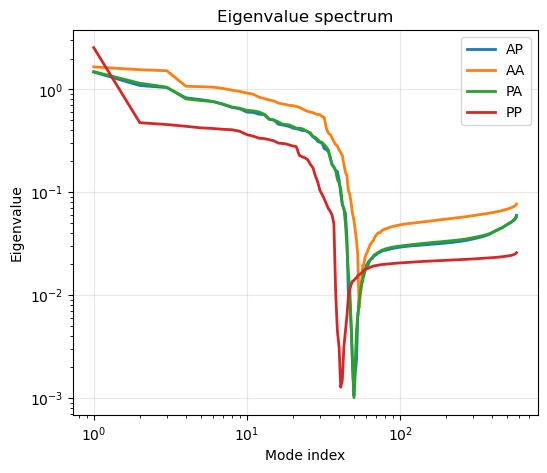

In [42]:
plt.figure(figsize=(6,5))

for sector, S in sector_spectral.items():

    eigs = np.abs(S["eigs"])

    plt.loglog(
        np.arange(1, len(eigs)+1),
        eigs,
        lw=2,
        label=sector
    )

plt.xlabel("Mode index")
plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Eigenvalue spectrum")
plt.show()

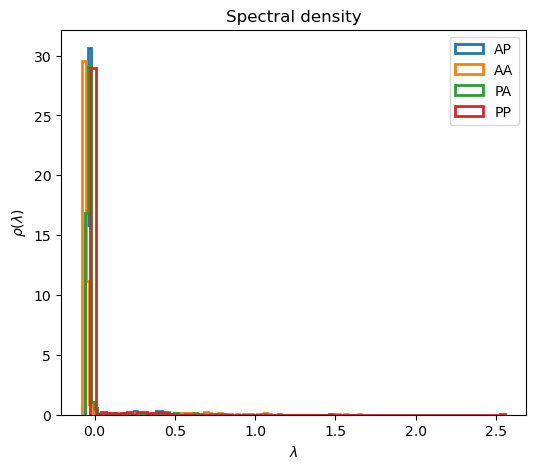

In [43]:
plt.figure(figsize=(6,5))

for sector, S in sector_spectral.items():

    plt.hist(
        S["eigs"],
        bins=80,
        density=True,
        histtype="step",
        linewidth=2,
        label=sector
    )

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda)$")
plt.legend()
plt.title("Spectral density")
plt.show()

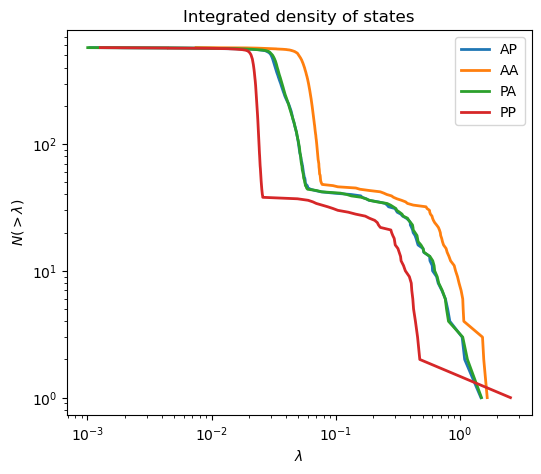

In [44]:
plt.figure(figsize=(6,5))

for sector, S in sector_spectral.items():

    eigs = np.sort(np.abs(S["eigs"]))[::-1]

    N = np.arange(1, len(eigs)+1)

    plt.loglog(
        eigs,
        N,
        lw=2,
        label=sector
    )

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$N(>\lambda)$")
plt.legend()
plt.title("Integrated density of states")
plt.show()

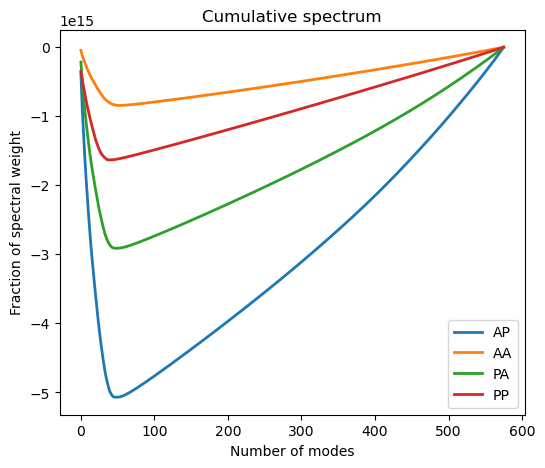

In [50]:
plt.figure(figsize=(6,5))

for sector, S in sector_spectral.items():

    plt.plot(
        S["cumulative"],
        lw=2,
        label=sector
    )

plt.xlabel("Number of modes")
plt.ylabel("Fraction of spectral weight")
plt.legend()
plt.title("Cumulative spectrum")
plt.show()

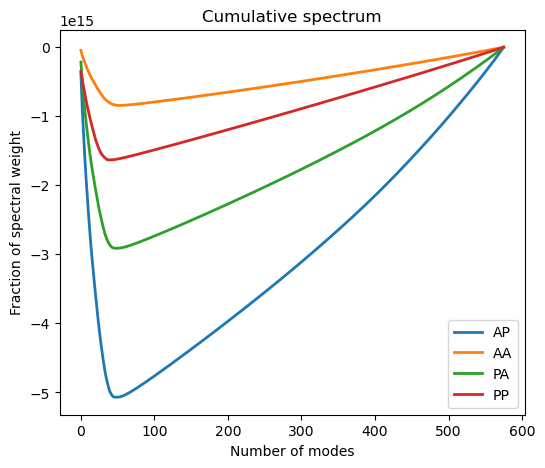

In [51]:
plt.figure(figsize=(6,5))

for sector, S in sector_spectral.items():

    plt.plot(
        S["cumulative"],
        lw=2,
        label=sector
    )

plt.xlabel("Number of modes")
plt.ylabel("Fraction of spectral weight")
plt.legend()
plt.title("Cumulative spectrum")
plt.show()

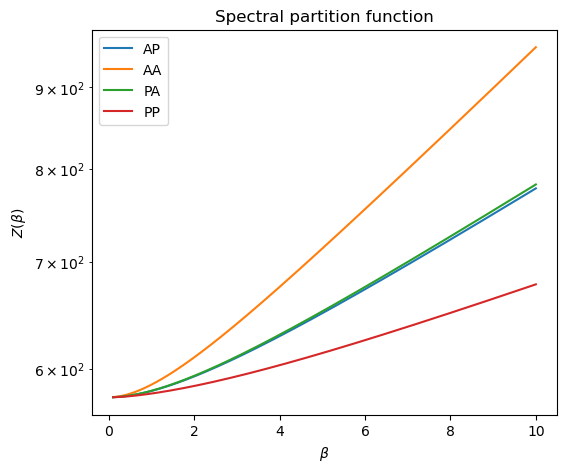

In [52]:
def spectral_partition(unique, mult, beta):

    return np.sum(
        mult * np.exp(-beta * unique)
    )

betas = np.linspace(0.1,10,200)

plt.figure(figsize=(6,5))

for sector, S in sector_spectral.items():

    Z = [
        spectral_partition(
            S["unique"],
            S["mult"],
            b
        )
        for b in betas
    ]

    plt.semilogy(
        betas,
        Z,
        label=sector
    )

plt.xlabel(r"$\beta$")
plt.ylabel(r"$Z(\beta)$")
plt.legend()
plt.title("Spectral partition function")
plt.show()

In [53]:
import matplotlib.pyplot as plt

def plot_eigenvalue_degeneracy_2d(sector_spectral, loglog=True):
    """
    2D plot of eigenvalues vs multiplicities for multiple sectors
    """
    plt.figure(figsize=(6,5))

    for sector, S in sector_spectral.items():

        x = S["unique"]
        y = S["mult"]

        if loglog:
            plt.loglog(x, y, 'o-', label=sector)
            plt.xlabel(r"Eigenvalue $\lambda$")
            plt.ylabel(r"Multiplicity $g(\lambda)$")
        else:
            plt.plot(x, y, 'o-', label=sector)
            plt.xlabel(r"Eigenvalue $\lambda$")
            plt.ylabel(r"Multiplicity $g(\lambda)$")

    plt.title("Eigenvalue vs Degeneracy")
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [57]:
def plot_eigenvalue_degeneracy_hist2d(sector_spectral, bins=50):
    plt.figure(figsize=(6,5))
    
    all_x = []
    all_y = []
    
    for sector, S in sector_spectral.items():
        all_x.extend(S["unique"])
        all_y.extend(S["mult"])
    
    plt.hist2d(
        all_x, all_y,
        bins=bins,
        cmap='plasma',
        cmin=1
    )
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Eigenvalue $\lambda$')
    plt.ylabel(r'Multiplicity $g(\lambda)$')
    plt.colorbar(label='Counts')
    plt.title("2D Histogram of Eigenvalue Degeneracies")
    plt.tight_layout()
    plt.show()

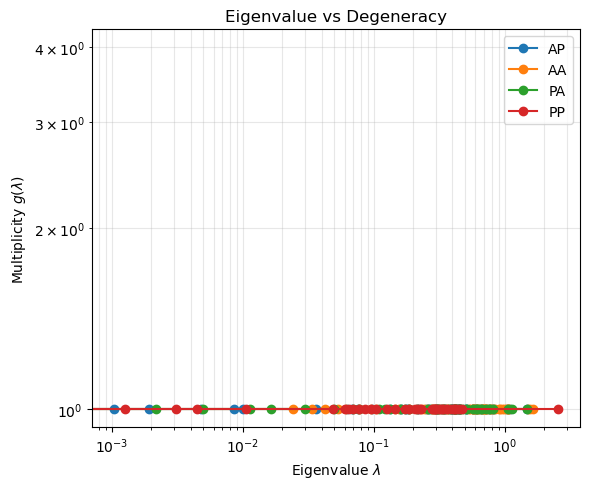

In [55]:
plot_eigenvalue_degeneracy_2d(sector_spectral)

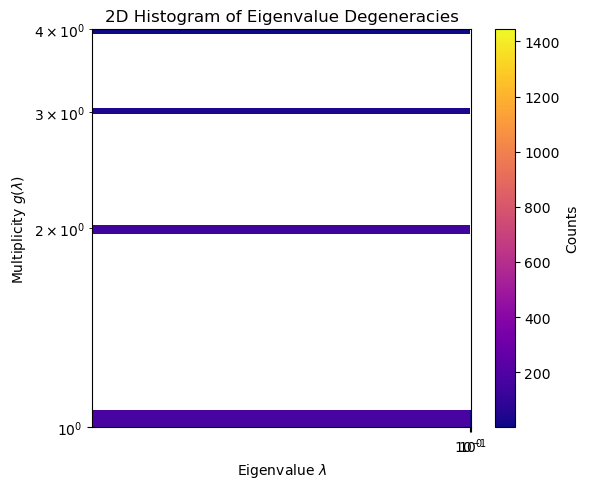

In [58]:
plot_eigenvalue_degeneracy_hist2d(sector_spectral)

In [61]:
def zero_fraction(eigs, tol=1e-2):
    eigs = np.array(eigs)
    return np.sum(np.abs(eigs) < tol) / len(eigs)

for sector, S in sector_spectral.items():
    print(f"{sector}: zero fraction = {zero_fraction(S['eigs'])*100:.1f}%")

AP: zero fraction = 1.4%
AA: zero fraction = 0.2%
PA: zero fraction = 1.2%
PP: zero fraction = 1.4%


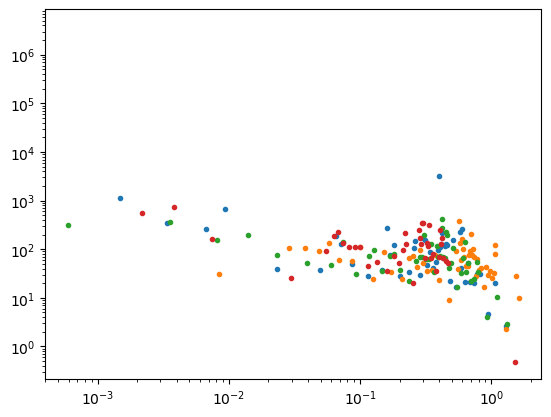

In [64]:
for sector, S in sector_spectral.items():

    eigs = np.sort(S['eigs'])[::-1]
    
    lam = 0.5*(eigs[:-1] + eigs[1:])
    rho = 1.0 / np.abs(np.diff(eigs))
    
    plt.loglog(lam, rho, '.')

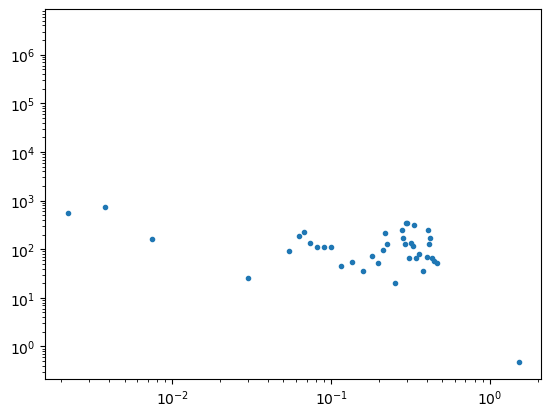

In [66]:
eigs = np.sort(eigs)[::-1]

lam = 0.5*(eigs[:-1] + eigs[1:])
rho = 1.0 / np.abs(np.diff(eigs))

plt.loglog(lam, rho, '.')

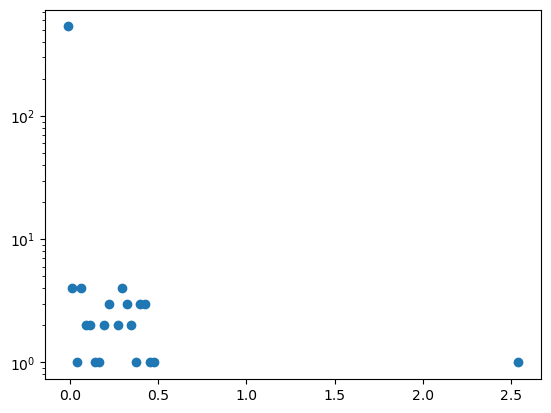

In [65]:
hist, edges = np.histogram(
    eigs,
    bins=100
)

centers = 0.5*(edges[:-1]+edges[1:])

plt.semilogy(
    centers,
    hist,
    'o'
)